In [1]:
import sys
sys.path.insert(0, "..")  # so we can import from src/

import matplotlib.pyplot as plt
import pandas as pd
from src.data.storage import get_connection, load_prices

# Connect and load all 10 tickers from 2015-2024
conn = get_connection("../data/market.duckdb")
df = load_prices(conn, start="2015-01-01")
df["date"] = pd.to_datetime(df["date"])

# Sanity check
print(f"Loaded {len(df):,} rows")
print(f"Tickers: {sorted(df['ticker'].unique())}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
df.head()

Loaded 25,150 rows
Tickers: ['AAPL', 'BAC', 'CVX', 'JNJ', 'JPM', 'KO', 'MSFT', 'PEP', 'PFE', 'XOM']
Date range: 2015-01-02 to 2024-12-30


,ticker,date,open,high,low,close,adj_close,volume
0,AAPL,2015-01-02,27.847500,27.860001,26.837500,27.332500,24.192604,212818400
1,AAPL,2015-01-05,27.072500,27.162500,26.352501,26.562500,23.511061,257142000
2,AAPL,2015-01-06,26.635000,26.857500,26.157499,26.565001,23.513273,263188400
3,AAPL,2015-01-07,26.799999,27.049999,26.674999,26.937500,23.842983,160423600
4,AAPL,2015-01-08,27.307501,28.037500,27.174999,27.972500,24.759079,237458000


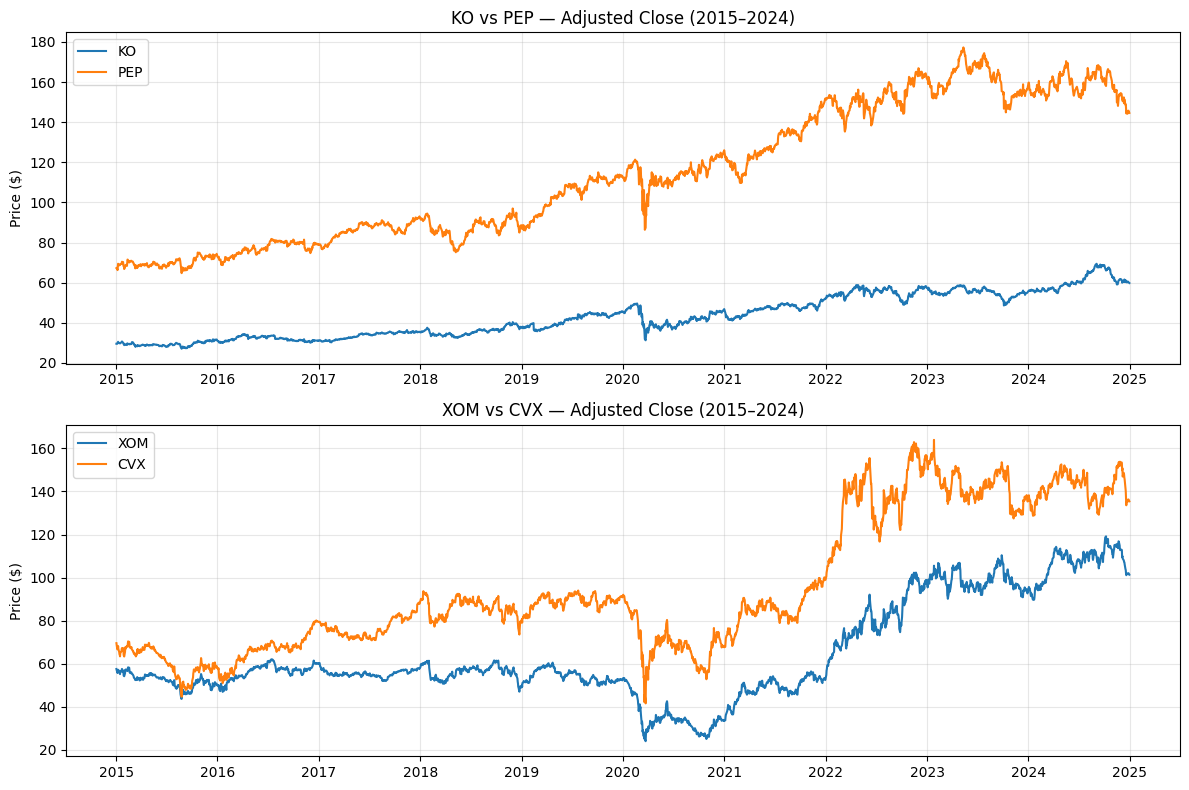

In [2]:
# Plot the two classic cointegration candidates: KO/PEP (beverages) and XOM/CVX (oil majors)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for pair, ax in zip([("KO", "PEP"), ("XOM", "CVX")], axes):
    for ticker in pair:
        sub = df[df["ticker"] == ticker]
        ax.plot(sub["date"], sub["adj_close"], label=ticker, linewidth=1.5)
    ax.set_title(f"{pair[0]} vs {pair[1]} — Adjusted Close (2015–2024)")
    ax.set_ylabel("Price ($)")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

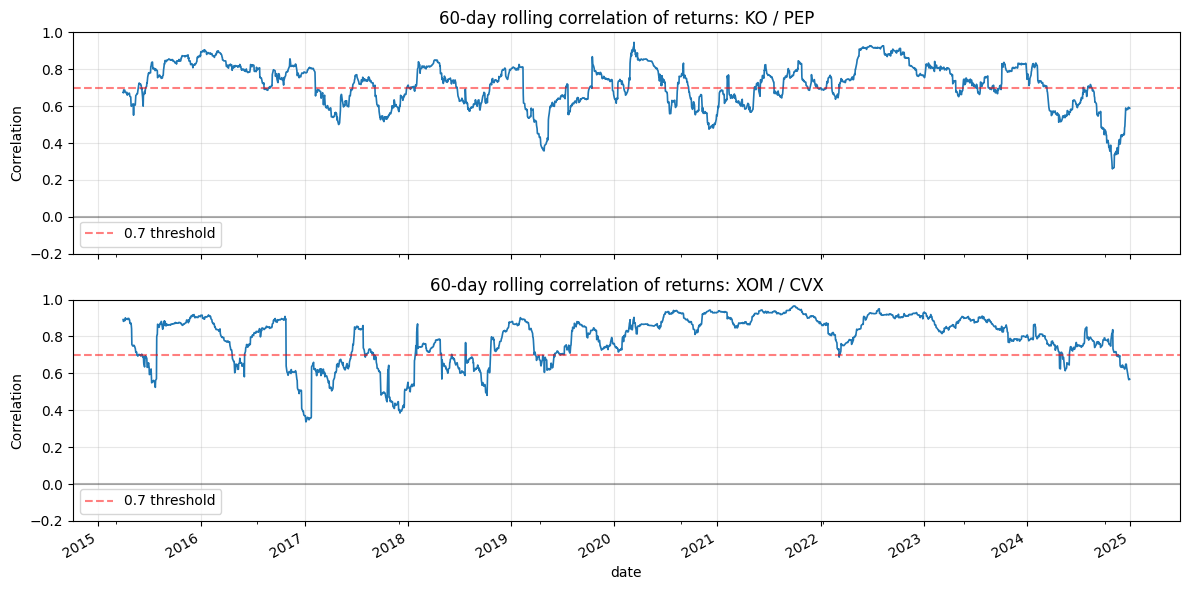

In [3]:
def rolling_corr(df, t1, t2, window=60):
    """Compute rolling correlation of daily returns between two tickers."""
    p1 = df[df["ticker"] == t1].set_index("date")["adj_close"]
    p2 = df[df["ticker"] == t2].set_index("date")["adj_close"]
    aligned = pd.concat([p1.rename(t1), p2.rename(t2)], axis=1).dropna()
    
    # Use returns, not prices — correlation of prices is misleading for trending series
    returns = aligned.pct_change().dropna()
    return returns[t1].rolling(window).corr(returns[t2])

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for (t1, t2), ax in zip([("KO", "PEP"), ("XOM", "CVX")], axes):
    rolling_corr(df, t1, t2, window=60).plot(ax=ax, linewidth=1.2)
    ax.set_title(f"60-day rolling correlation of returns: {t1} / {t2}")
    ax.set_ylabel("Correlation")
    ax.axhline(0.7, color="red", linestyle="--", alpha=0.5, label="0.7 threshold")
    ax.axhline(0, color="black", linestyle="-", alpha=0.3)
    ax.legend(loc="lower left")
    ax.grid(alpha=0.3)
    ax.set_ylim(-0.2, 1.0)

plt.tight_layout()
plt.show()

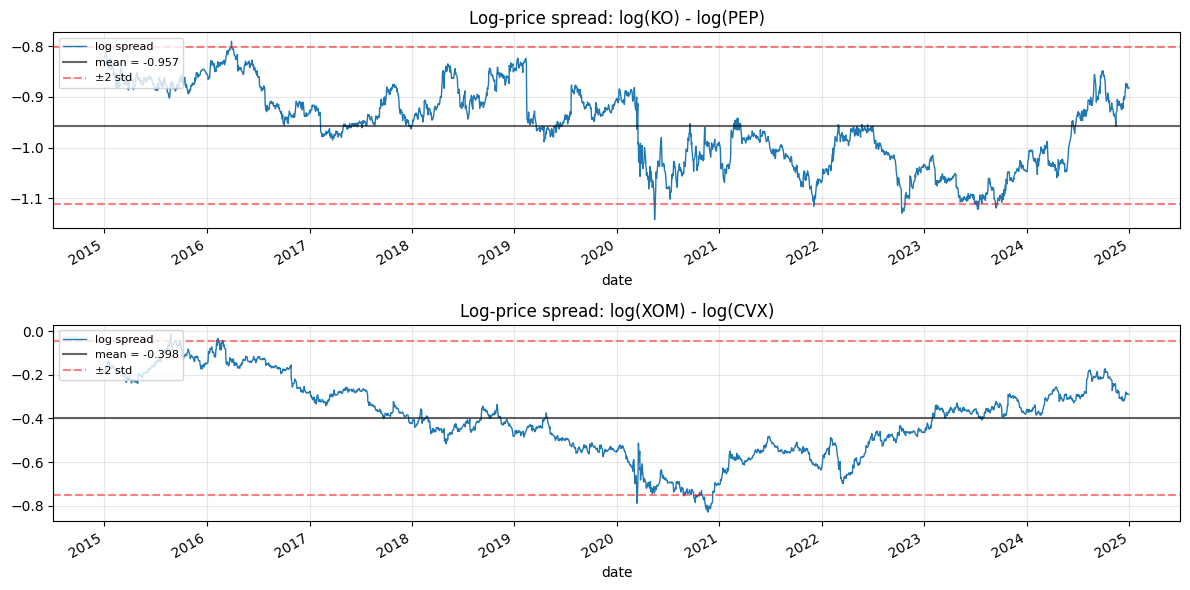

In [4]:
# The "spread" is what pairs trading actually trades.
# For now, use a simple log-price spread; we'll formalize with cointegration regression later.

import numpy as np

def compute_spread(df, t1, t2):
    p1 = df[df["ticker"] == t1].set_index("date")["adj_close"]
    p2 = df[df["ticker"] == t2].set_index("date")["adj_close"]
    aligned = pd.concat([np.log(p1).rename(t1), np.log(p2).rename(t2)], axis=1).dropna()
    spread = aligned[t1] - aligned[t2]
    return spread

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

for (t1, t2), ax in zip([("KO", "PEP"), ("XOM", "CVX")], axes):
    spread = compute_spread(df, t1, t2)
    mean = spread.mean()
    std = spread.std()
    
    spread.plot(ax=ax, linewidth=1.0, label="log spread")
    ax.axhline(mean, color="black", linestyle="-", alpha=0.6, label=f"mean = {mean:.3f}")
    ax.axhline(mean + 2*std, color="red", linestyle="--", alpha=0.5, label="±2 std")
    ax.axhline(mean - 2*std, color="red", linestyle="--", alpha=0.5)
    ax.set_title(f"Log-price spread: log({t1}) - log({t2})")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()